# TACO flow-matching RL: smoke check (env + policy + PPO plumbing)

Validates the `feat/taco-allegro-flow-rl` integration on **real** TACO episodes and a **real** flow-policy checkpoint:

1. `TacoEnv` reset / chunk_step (point clouds re-posed from live sim state);
2. noise-injected rollout (`flow_sde`, piRL-style) + tracking reward;
3. **ODE parity**: eval-mode sampler must equal the original IL sampler;
4. **PPO log-prob parity**: training forward on stored chains must match rollout log-probs;
5. backward pass through a PPO-style surrogate.

Checkpoint: `/root/flow-policy/outputs/flow-policy/2026-06-10/18-12-14/checkpoints/best.pt`

In [1]:
import sys, time
sys.path.insert(0, '/root/RLinf')
sys.path.insert(0, '/root/RLinf/examples/embodiment/taco_allegro')
import numpy as np, torch
import matplotlib.pyplot as plt
from types import SimpleNamespace
from smoke_test import build_env_cfg, build_model_cfg

CKPT = '/root/flow-policy/outputs/flow-policy/2026-06-10/18-12-14/checkpoints/best.pt'
state = torch.load(CKPT, map_location='cpu', weights_only=False)
sm = state['shape_meta']
args = SimpleNamespace(
    ckpt=CKPT,
    dataset_root='/root/Data/taco-brush-allegro',
    allegro_assets='/root/Spider/spider/assets/robots/allegro/assets',
    scene_root='/tmp/taco_smoke_nb_scene_root',
    trajectory_file='trajectory_ctrl_30hz_im.npz',
    num_envs=4, num_chunk_steps=8, num_action_chunks=4, max_steps=32,
    obs_mode=sm['obs_mode'], obs_horizon=int(sm['obs_horizon']),
    num_points=int(sm['num_points']),
)
del state
print('shape_meta:', dict(sm))

shape_meta: {'action_dim': 44, 'obs_mode': 'pc2_qpos', 'obs_horizon': 16, 'pred_horizon': 16, 'action_horizon': 4, 'action_offset': 1, 'point_dim': 3, 'num_points': 512, 'lowdim_dim': 44, 'qpos_dim': 44}


In [2]:
from rlinf.models import get_model
from rlinf.envs import get_env_cls

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_model(build_model_cfg(args)).to(device).eval()
print(f'model: {sum(p.numel() for p in model.parameters())/1e6:.2f}M params on {device}')

env_cfg = build_env_cfg(args)
env = get_env_cls('taco', env_cfg)(cfg=env_cfg, num_envs=args.num_envs,
                                   seed_offset=0, total_num_processes=1, worker_info=None)
obs, _ = env.reset()
print('episodes:', [s.episode.name for s in env.subenvs])
for k, v in obs.items():
    print(f'  obs[{k}]: {tuple(v.shape)} {v.dtype}')

/root/RLinf/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-11 19:12:27,700	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


model: 8.74M params on cuda


episodes: ['brush__brush__bowl__20230927_027', 'brush__brush__helmet__20230919_040', 'brush__brush__box__20230927_029', 'brush__brush__bowl__20230927_027']
  obs[states]: (4, 16, 44) torch.float32
  obs[pointcloud]: (4, 16, 512, 3) torch.float32
  obs[tool_pointcloud]: (4, 16, 512, 3) torch.float32


## Rollout (train mode, noise-injected) + tracking reward

rollout: 0.9s (146 env-steps/s)
final tool_pos_err_final_m: [0.076 0.019 0.04  0.005]
success (<0.1m): [ True  True  True  True]


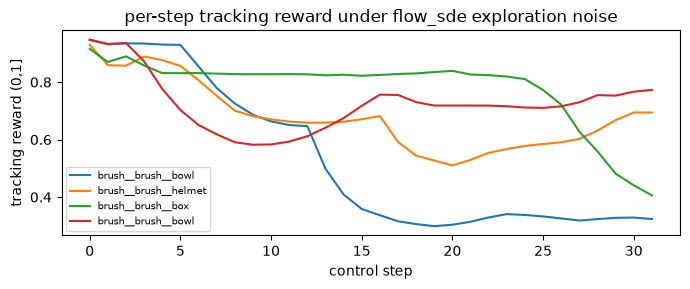

In [3]:
per_step_fi, per_step_logp = [], []
step_rewards = []  # (T, B)
t0 = time.time()
for step in range(args.num_chunk_steps):
    with torch.no_grad():
        actions, result = model.predict_action_batch(env_obs=obs, mode='train')
    per_step_fi.append(result['forward_inputs'])
    per_step_logp.append(result['prev_logprobs'])
    obs_list, rewards, terms, truncs, infos = env.chunk_step(actions.numpy())
    obs = obs_list[-1]
    step_rewards.append(rewards.numpy())  # (B, chunk)
dt = time.time() - t0
step_rewards = np.concatenate(step_rewards, axis=1)  # (B, T*chunk)
print(f'rollout: {dt:.1f}s '
      f'({args.num_envs*args.num_chunk_steps*args.num_action_chunks/dt:.0f} env-steps/s)')
ep = infos[-1]['episode']
print('final tool_pos_err_final_m:', ep['tool_pos_err_final_m'].numpy().round(3))
print('success (<0.1m):', ep['success_once'].numpy())

fig, ax = plt.subplots(figsize=(7, 3))
for i in range(args.num_envs):
    ax.plot(step_rewards[i], label=env.subenvs[i].episode.category)
ax.set_xlabel('control step'); ax.set_ylabel('tracking reward (0,1]')
ax.set_title('per-step tracking reward under flow_sde exploration noise')
ax.legend(fontsize=7); fig.tight_layout(); plt.show()

## Parity check 1 - eval-mode sampler == original IL flow ODE

In [4]:
from flow_policy.algos.flow_matching import FlowMatching
from flow_policy.data.normalizer import Normalizer
from flow_policy.models.transformer_policy import FlowMatchingTransformerPolicy

state = torch.load(CKPT, map_location='cpu', weights_only=False)
mcfg = {k: v for k, v in state['cfg']['model'].items() if k != '_target_'}
ref = FlowMatching(
    model=FlowMatchingTransformerPolicy(shape_meta=sm, **mcfg),
    normalizer=Normalizer(sm['action_dim'], sm['obs_mode'],
                          point_dim=sm['point_dim'], qpos_dim=sm['qpos_dim']),
    num_sample_steps=state['cfg']['algo'].get('num_sample_steps', 16),
    normalize_obs=state['cfg']['algo'].get('normalize_obs', True),
)
ref.model.load_state_dict(state['model']); ref.normalizer.load_state_dict(state['normalizer'])
ref = ref.to(device).eval()

fp_obs = {'pointcloud': obs['pointcloud'].to(device), 'qpos': obs['states'].to(device)}
if args.obs_mode == 'pc2_qpos':
    fp_obs['tool_pointcloud'] = obs['tool_pointcloud'].to(device)
torch.manual_seed(123)
with torch.no_grad():
    ref_chunk = ref.sample(fp_obs)
torch.manual_seed(123)
with torch.no_grad():
    _, eval_result = model.predict_action_batch(env_obs=obs, mode='eval')
rl_chunk = eval_result['forward_inputs']['model_action'].reshape(args.num_envs, -1, 44)
ode_err = (ref_chunk.cpu() - rl_chunk).abs().max().item()
print(f'ODE parity max|diff| = {ode_err:.2e}')
assert ode_err < 1e-4

ODE parity max|diff| = 4.77e-07


## Parity check 2 - PPO log-prob recompute + backward pass

In [5]:
fi = {k: torch.cat([s[k] for s in per_step_fi], dim=0) for k in per_step_fi[0]}
prev_logp = torch.cat(per_step_logp, dim=0)
model.train()
out = model(forward_inputs=fi, compute_logprobs=True, compute_values=True)
logp = out['logprobs']
logp_err = (logp.detach().cpu().float() - prev_logp.float()).abs().max().item()
print(f'logprob parity max|diff| = {logp_err:.2e}')
assert logp_err < 1e-3

bsz = logp.shape[0]
adv = torch.randn(bsz, device=logp.device)
ratio = torch.exp(logp.reshape(bsz, -1).sum(-1)
                  - prev_logp.to(logp.device).reshape(bsz, -1).sum(-1))
loss = -(adv * ratio).mean() + out['values'].pow(2).mean()
loss.backward()
gsum = sum(p.grad.abs().sum().item() for p in model.parameters() if p.grad is not None)
print(f'ratio at parity: mean={ratio.mean().item():.4f} (should be ~1)')
print(f'backward ok: total |grad| = {gsum:.3e}')
assert gsum > 0
env.close()
print('ALL CHECKS PASSED')

logprob parity max|diff| = 4.40e-04
ratio at parity: mean=1.0000 (should be ~1)
backward ok: total |grad| = 6.865e+04
ALL CHECKS PASSED
